In [1]:
# !pip install numpy
# !pip install pandas
# !pip install matplotlib

In [37]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [38]:
def load_csv_files(start_year=2004, end_year=2004):
    """
    Loads the indication-reaction, indication-drug, and drug-reaction association CSV files into Pandas DataFrames.

    Parameters:
        start_year (int): The start year of the dataset.
        end_year (int): The end year of the dataset.

    Returns:
        tuple: (ind_rea_df, ind_drug_df, drug_rea_df)
    """
    # Define directory path
    results_dir = f'../results/{start_year}-{end_year}'

    confounders = {
        'ind': 'indication',
        'drug': 'drug',
        'sex': 'sex',
        'age': 'age'
    }
    file_paths = dict()
    for ccode, cname in confounders.items():
        file_paths[f"{ccode}_rea_df"] = f"{cname}_reaction_associations.csv"
        file_paths[f"{ccode}_drug_df"] = f"{cname}_drug_associations.csv"
    
    dfs = dict()
    for dfkey, filename in file_paths.items():
        file_path = os.path.join(results_dir, filename)
        # Load CSVs into DataFrames
        try:
            dfs[dfkey] = pd.read_csv(file_path)
            print(f"Loaded {len(dfs[dfkey])} rows from {file_path}. Stored at key: {dfkey}")
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
            dfs[dfkey] = None

    return dfs

In [39]:
def confounder_drug_reaction_correlation(
    ind_rea_df, ind_drug_df, drug_rea_df, 
    conf_rea_threshold=100, min_threshold_for_drug=40, num_bins=30, type='proportion',
    conf_rea_col = 'PRR', conf_drug_col = 'PHI', drug_rea_col = 'PRR',
    conf_col_name='indication', title=None
):
    """
    Plots:
    - X-axis: Average PHI (conf_drug_col) in equally sized bins of drugs.
    - Y-axis: Mean (or Proportion of drugs in each bin with statistic (drug_rea_col) > min_threshold_for_drug) for the indication's reactions.

    Parameters:
        ind_rea_df (pd.DataFrame): DataFrame with confounder-reaction associations. Initially implemented with indications, but can be other things.
        ind_drug_df (pd.DataFrame): DataFrame with confounder-drug associations. Initiatlly implemented with indications, but can be other things. 
        drug_rea_df (pd.DataFrame): DataFrame with drug-reaction associations.
        ind_rea_threshold (float): Threshold for identifying strong confounder-reaction links. Note used if type == 'mean'
        min_threshold_for_drug (float): PRR threshold for drugs.
        num_bins (int): Number of bins to group drugs based on PHI.
        type (str): 'proportion' or 'mean' to indicate to plot proportion above threshold or mean.
        conf_col (str): Which reaction association statistic to use in the confounder matrix. 
        drug_col (str): which reaction association statistic to use in the drug matrix.
        title (str): override the title

    Returns:
        data (pd.DataFrame): DataFrame with possibly confounded drug-reaction associations.
    """
    
    indication_reactions = ind_rea_df[ind_rea_df[conf_rea_col]>conf_rea_threshold]
    
    data = None
    for ind in indication_reactions[conf_col_name].unique():
        relevant_reactions = list(set(indication_reactions[indication_reactions[conf_col_name] == ind]["reaction"]))
        id = ind_drug_df[ind_drug_df[conf_col_name]==ind]
        dr = drug_rea_df[drug_rea_df['reaction'].isin(relevant_reactions)]
        re = id.merge(dr, on="drug", suffixes=['_conf_drug', '_drug_rea'])[[conf_col_name, 'reaction', 'drug', f'{conf_drug_col}_conf_drug', f'{drug_rea_col}_drug_rea']]
        if data is None:
            data = re
        else:
            data = pd.concat([data, re], ignore_index=True)

    sorted_data = data.sort_values(by=f'{conf_drug_col}_conf_drug')

    plot_data = list()
    for b, df in enumerate(np.array_split(sorted_data, num_bins)):
        yprop = (df[f'{drug_rea_col}_drug_rea'] > min_threshold_for_drug).sum()/df[f'{drug_rea_col}_drug_rea'].shape[0]
        ymu = df[f'{drug_rea_col}_drug_rea'].mean()
        xmu = df[f'{conf_drug_col}_conf_drug'].mean()
        #print(b, xmu, ymu, yprop)
        plot_data.append((xmu, ymu, yprop))

    x, ymu, yprop = zip(*plot_data)
    if type == 'proportion':
        y = yprop
        ylabel = f"Proportion of Drugs with {drug_rea_col} > {min_threshold_for_drug}"
    elif type == 'mean':
        y = ymu
        ylabel = f"Average {drug_rea_col}"
    else:
        raise Exception(f"Unknown type provided: {type}")
    
    plt.figure(figsize=(8, 6))
    plt.scatter(x,y,color='k')

    plt.xlabel(f"Average {conf_drug_col} in Bin")
    plt.ylabel(ylabel)
    if title is not None:
        plt.title(title)
    else:
        plt.title(f"Drug-{conf_col_name.title()} Correlation vs. Drug-Reaction Proportion (Binned)")

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    return data


In [40]:
# Load DataFrames
start_year = 2004
end_year = 2004
dfs = load_csv_files(start_year, end_year)

Loaded 11212 rows from ../results/2004-2004/indication_reaction_associations.csv. Stored at key: ind_rea_df
Loaded 17371 rows from ../results/2004-2004/indication_drug_associations.csv. Stored at key: ind_drug_df
Loaded 32450 rows from ../results/2004-2004/drug_reaction_associations.csv. Stored at key: drug_rea_df
Loaded 27660 rows from ../results/2004-2004/drug_drug_associations.csv. Stored at key: drug_drug_df
Loaded 7202 rows from ../results/2004-2004/sex_reaction_associations.csv. Stored at key: sex_rea_df
Loaded 605 rows from ../results/2004-2004/sex_drug_associations.csv. Stored at key: sex_drug_df
Loaded 9831 rows from ../results/2004-2004/age_reaction_associations.csv. Stored at key: age_rea_df
Loaded 1499 rows from ../results/2004-2004/age_drug_associations.csv. Stored at key: age_drug_df


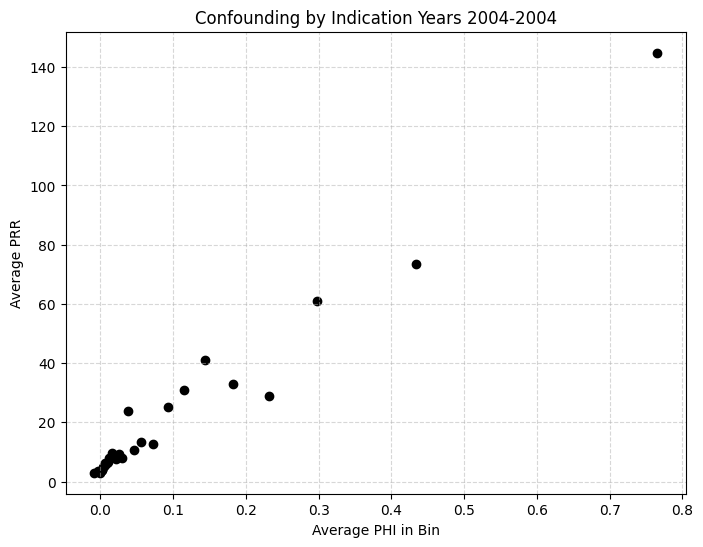

(8070, 5)

In [10]:
indications = confounder_drug_reaction_correlation(
    dfs['ind_rea_df'],  # DataFrame for confounder-reaction links
    dfs['ind_drug_df'], # DataFrame for confounder-drug links
    dfs['drug_rea_df'], # DataFrame for drug-reaction links
    conf_rea_threshold=10,  # Identify strong indication-reaction links
    min_threshold_for_drug=40,  # Threshold for PRR in drugs
    num_bins=30, # Number of bins to group data in plot
    type='mean', # calculate proportion above threshold or mean
    conf_rea_col = 'PRR', # statistic to use for confounder-reaction relationship
    conf_drug_col = 'PHI', # statistic to use for confounder-drug relationship
    drug_rea_col = 'PRR', # statistic to use for drug-reaction relationship
    conf_col_name='indication', # name of confounder
    title = f'Confounding by Indication Years {start_year}-{end_year}',
)

indications.shape

In [11]:
indications.sort_values(by='PRR_drug_rea', ascending=False).head(20)

,indication,reaction,drug,PHI_conf_drug,PRR_drug_rea
2418,CONTRACEPTION,MEDICAL DEVICE DISCOMFORT,ETONOGESTREL AND ETHINYL ESTRADIOL,0.778266,6992.496357
3288,ECZEMA,APPLICATION SITE DRYNESS,PIMECROLIMUS,0.714252,4527.821615
2428,CONTRACEPTION,WITHDRAWAL BLEEDING IRREGULAR,ETONOGESTREL AND ETHINYL ESTRADIOL,0.778266,3750.165644
40,ABORTION INDUCED,ABORTION INCOMPLETE,MISOPROSTOL,0.299006,3388.999337
3231,DRUG USE FOR UNKNOWN INDICATION,LIVE BIRTH,ISOTRETINOIN,0.149459,3202.692555
3896,HODGKIN'S DISEASE,AZOOSPERMIA,VINBLASTINE SULFATE,0.511226,2706.760563
593,ANTIVIRAL PROPHYLAXIS,RESPIRATORY SYNCYTIAL VIRUS INFECTION,PALIVIZUMAB,0.702043,2482.011743
3892,HODGKIN'S DISEASE,AZOOSPERMIA,DOXORUBICIN,0.039969,2432.563291
3910,HORMONE REPLACEMENT THERAPY,BREAST OPERATION,CONJUGATED ESTROGENS AND MEDROXYPROGESTERONE A...,0.609629,2317.829744
3888,HODGKIN'S DISEASE,AZOOSPERMIA,"BLEOMYCIN,BLEOMYCIN SULFATE",0.366408,1574.853996


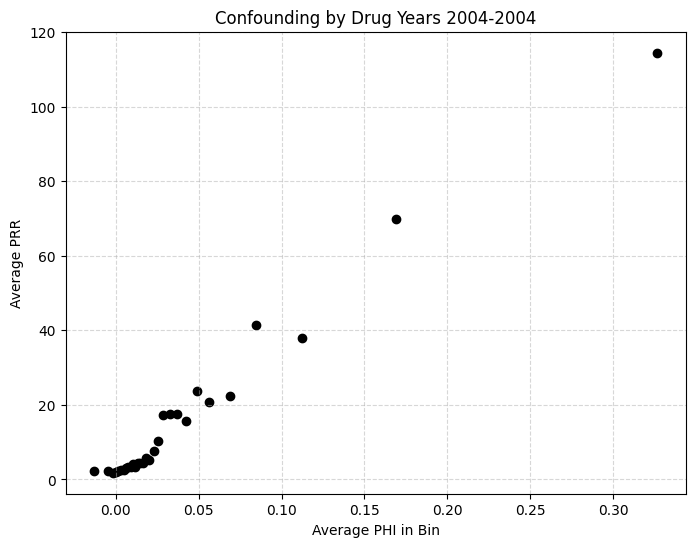

(17264, 5)

In [12]:
conf_drug_rea_df = dfs['drug_rea_df'].copy()
conf_drug_rea_df.rename(columns={'drug': 'conf_drug'}, inplace=True)

drugs = confounder_drug_reaction_correlation(
    conf_drug_rea_df,  # DataFrame for confounder-reaction links
    dfs['drug_drug_df'], # DataFrame for confounder-drug links
    dfs['drug_rea_df'], # DataFrame for drug-reaction links
    conf_rea_threshold=10,  # Identify strong indication-reaction links
    min_threshold_for_drug=40,  # Threshold for PRR in drugs
    num_bins=30, # Number of bins to group data in plot
    type='mean', # calculate proportion above threshold or mean
    conf_rea_col = 'PRR', # statistic to use for confounder-reaction relationship
    conf_drug_col = 'PHI', # statistic to use for confounder-drug relationship
    drug_rea_col = 'PRR', # statistic to use for drug-reaction relationship
    conf_col_name='conf_drug', # name of confounder
    title = f'Confounding by Drug Years {start_year}-{end_year}',
)

drugs.shape

In [13]:
drugs.sort_values(by='PRR_drug_rea', ascending=False).head(20)

,conf_drug,reaction,drug,PHI_conf_drug,PRR_drug_rea
10348,LIDOCAINE HYDROCHLORIDE AND EPINEPHRINE BITART...,ENDOPHTHALMITIS,BALANCED SALT SOLUTION,0.245818,4499.332288
11479,MIFEPRISTONE,ABORTION INCOMPLETE,MISOPROSTOL,0.305565,3388.999337
16899,VINCRISTINE SULFATE,AZOOSPERMIA,VINBLASTINE SULFATE,0.094963,2706.760563
4919,DOXORUBICIN,AZOOSPERMIA,VINBLASTINE SULFATE,0.240065,2706.760563
3491,"CYCLOPHOSPHAMIDE,CYCLOPHOSPHAMIDE FOR INJECTIO...",AZOOSPERMIA,VINBLASTINE SULFATE,0.046943,2706.760563
1804,"BLEOMYCIN,BLEOMYCIN SULFATE",AZOOSPERMIA,VINBLASTINE SULFATE,0.366543,2706.760563
14006,PREDNISONE,AZOOSPERMIA,VINBLASTINE SULFATE,0.028566,2706.760563
3333,"CYCLOPHOSPHAMIDE,CYCLOPHOSPHAMIDE FOR INJECTIO...",COMPLICATIONS OF BONE MARROW TRANSPLANT,BUSULFAN,0.162540,2661.441558
16859,VINBLASTINE SULFATE,AZOOSPERMIA,DOXORUBICIN,0.240065,2432.563291
16877,VINCRISTINE SULFATE,AZOOSPERMIA,DOXORUBICIN,0.221692,2432.563291


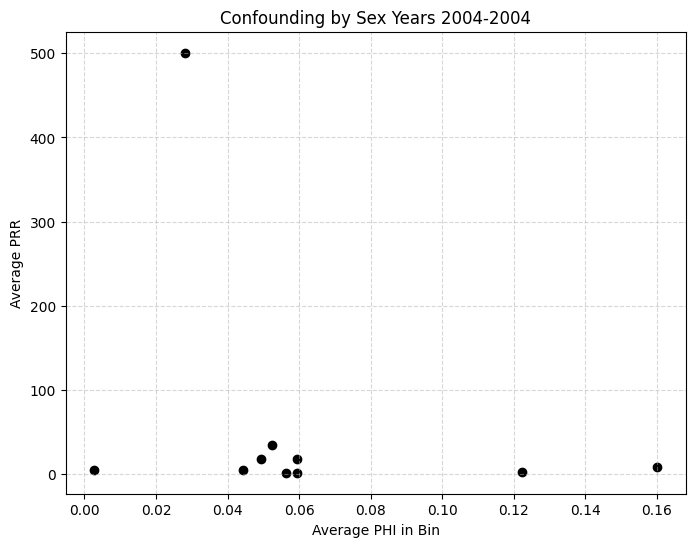

(22, 5)

In [33]:
sexes = confounder_drug_reaction_correlation(
    dfs['sex_rea_df'],  # DataFrame for confounder-reaction links
    dfs['sex_drug_df'], # DataFrame for confounder-drug links
    dfs['drug_rea_df'], # DataFrame for drug-reaction links
    conf_rea_threshold=30,  # Identify strong indication-reaction links
    min_threshold_for_drug=None,  # Threshold for PRR in drugs
    num_bins=10, # Number of bins to group data in plot
    type='mean', # calculate proportion above threshold or mean
    conf_rea_col = 'PRR', # statistic to use for confounder-reaction relationship
    conf_drug_col = 'PHI', # statistic to use for confounder-drug relationship
    drug_rea_col = 'PRR', # statistic to use for drug-reaction relationship
    conf_col_name='sex', # name of confounder
    title = f'Confounding by Sex Years {start_year}-{end_year}',
)

sexes.shape

In [34]:
# sexes.sort_values(by='PRR_drug_rea', ascending=False).head(20)

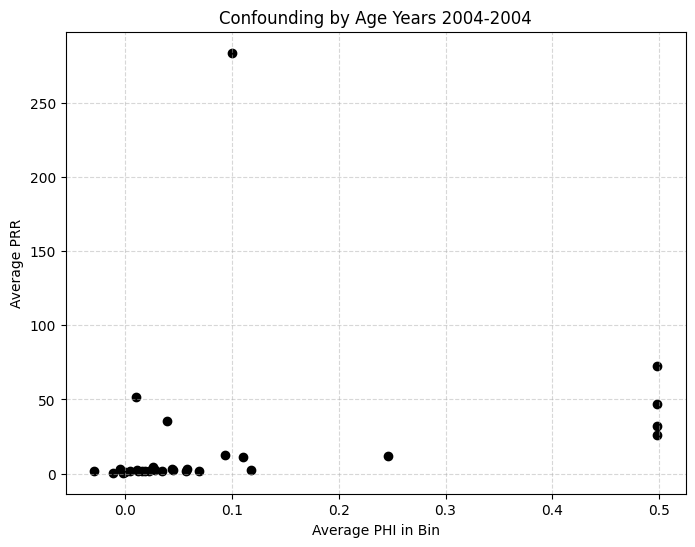

(115, 5)

In [41]:
ages = confounder_drug_reaction_correlation(
    dfs['age_rea_df'],  # DataFrame for confounder-reaction links
    dfs['age_drug_df'], # DataFrame for confounder-drug links
    dfs['drug_rea_df'], # DataFrame for drug-reaction links
    conf_rea_threshold=10,  # Identify strong indication-reaction links
    min_threshold_for_drug=None,  # Threshold for PRR in drugs
    num_bins=30, # Number of bins to group data in plot
    type='mean', # calculate proportion above threshold or mean
    conf_rea_col = 'PRR', # statistic to use for confounder-reaction relationship
    conf_drug_col = 'PHI', # statistic to use for confounder-drug relationship
    drug_rea_col = 'PRR', # statistic to use for drug-reaction relationship
    conf_col_name='age', # name of confounder
    title = f'Confounding by Age Years {start_year}-{end_year}',
)

ages.shape

In [42]:
ages.sort_values(by='PRR_drug_rea', ascending=False).head(20)

,age,reaction,drug,PHI_conf_drug,PRR_drug_rea
106,Younger,CRANIOPHARYNGIOMA,SOMATROPIN,0.096714,1121.632877
1,Middle,BLOOD HUMAN CHORIONIC GONADOTROPIN INCREASED,THALIDOMIDE,0.009333,199.920018
2,Middle,IMMUNE RECONSTITUTION SYNDROME,ZIDOVUDINE,0.041946,132.445548
27,Younger,PRESCRIBED OVERDOSE,ATOMOXETINE HYDROCHLORIDE,0.498580,122.428225
26,Younger,NEGATIVISM,ATOMOXETINE HYDROCHLORIDE,0.498580,95.428844
30,Younger,TIC,ATOMOXETINE HYDROCHLORIDE,0.498580,64.561737
20,Younger,EDUCATIONAL PROBLEM,ATOMOXETINE HYDROCHLORIDE,0.498580,47.714422
28,Younger,PSYCHOMOTOR HYPERACTIVITY,ATOMOXETINE HYDROCHLORIDE,0.498580,41.654872
65,Younger,BENIGN INTRACRANIAL HYPERTENSION,ISOTRETINOIN,0.089313,37.901687
23,Younger,IMPULSE-CONTROL DISORDER,ATOMOXETINE HYDROCHLORIDE,0.498580,35.626769
